<a href="https://colab.research.google.com/github/ken17102001/heat-pinns/blob/main/pinns20250121141153.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

20250123074925
cuda
epoch:0.000e+00,loss:9.569e+00,pinn:1.182e-05,ini:9.518e+00,bnd:5.068e-02
epoch:5.000e+02,loss:3.042e+00,pinn:9.597e-02,ini:2.622e+00,bnd:3.237e-01
epoch:1.000e+03,loss:8.712e-01,pinn:1.836e-01,ini:6.640e-01,bnd:2.371e-02
epoch:1.500e+03,loss:2.622e-01,pinn:5.533e-02,ini:1.976e-01,bnd:9.232e-03
epoch:2.000e+03,loss:1.531e-01,pinn:3.972e-02,ini:1.051e-01,bnd:8.245e-03
epoch:2.500e+03,loss:8.764e-02,pinn:2.642e-02,ini:5.593e-02,bnd:5.284e-03
epoch:3.000e+03,loss:5.168e-02,pinn:1.743e-02,ini:3.095e-02,bnd:3.304e-03
epoch:3.500e+03,loss:3.226e-02,pinn:1.065e-02,ini:1.880e-02,bnd:2.811e-03
epoch:4.000e+03,loss:2.148e-02,pinn:7.445e-03,ini:1.193e-02,bnd:2.103e-03
epoch:4.500e+03,loss:1.648e-02,pinn:6.128e-03,ini:8.930e-03,bnd:1.425e-03
epoch:5.000e+03,loss:1.337e-02,pinn:4.984e-03,ini:7.268e-03,bnd:1.120e-03
epoch:5.500e+03,loss:1.104e-02,pinn:4.056e-03,ini:6.120e-03,bnd:8.629e-04
epoch:6.000e+03,loss:9.252e-03,pinn:3.358e-03,ini:5.206e-03,bnd:6.882e-04
epoch:6.500e+03,lo

<ipython-input-2-0f7e901b0cfa>:253: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(
<ipython-input-2-0f7e901b0cfa>:280: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(


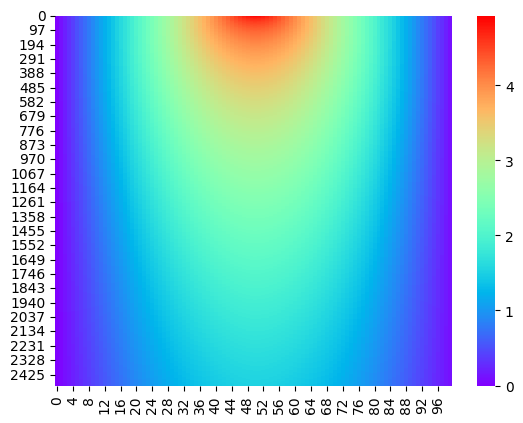

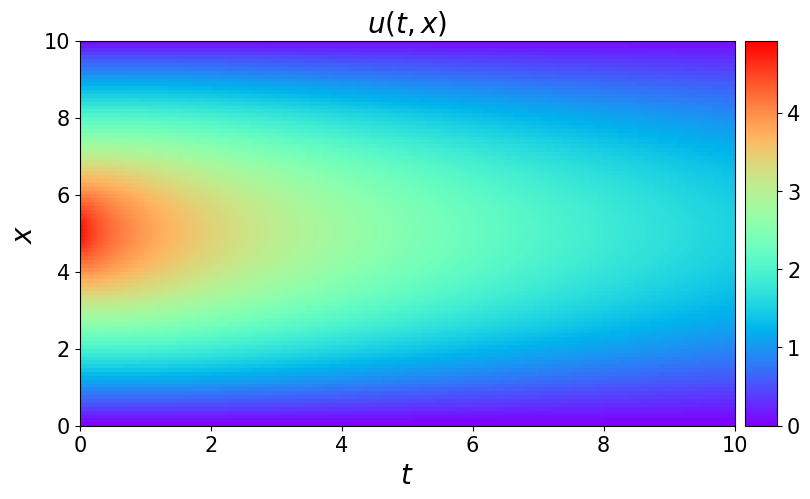

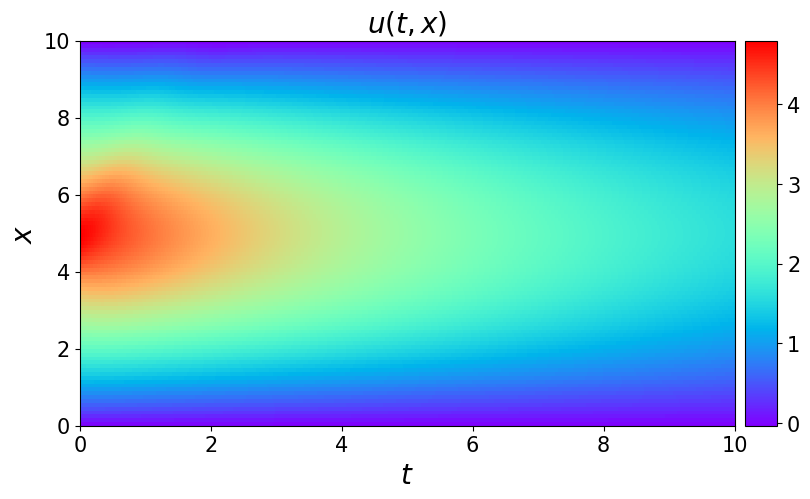

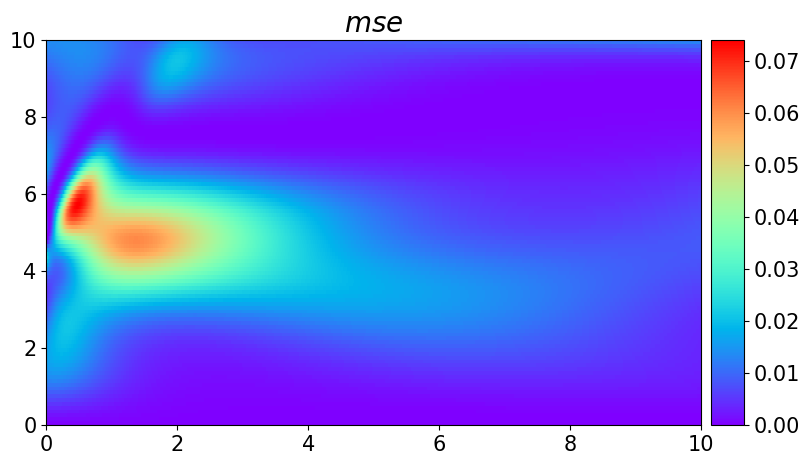

In [ ]:
from sre_constants import JUMP

import datetime
now = datetime.datetime.now()
time_now=now.strftime('%Y%m%d%H%M%S') #時刻
print(time_now)

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.io as sio
from scipy.io import loadmat
from scipy.interpolate import griddata
import torch
import torch.nn as nn
import torch.optim as optim
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.gridspec as gridspec
import torchvision.transforms as transforms
from torchvision.utils import save_image
from torch.utils.data import TensorDataset, DataLoader
from torchvision import datasets
from torch.autograd import Variable
import torch
import pylab as py
import time

device = 'cuda' if torch.cuda.is_available() else 'cpu'

print(device)
x_min, x_max = 0, 10  # 空間範囲 (例えば 0 <= x <= 10)
num_x = 100  # 空間方向の分割数

# 時間の範囲と分割数
t_min, t_max = 0, 10  # 時間範囲 (例えば 0 <= t <= 10)
num_t = 2500  # 時間方向の分割数 )

# 空間データと時間データを生成
x_exact = np.linspace(x_min, x_max, num_x)  # 空間方向の点
t_exact = np.linspace(t_min, t_max, num_t)  # 時間方向の点

# グリッドを生成
X, T = np.meshgrid(x_exact, t_exact)
Exact = np.load('/content/drive/MyDrive/Colab/temp_data.npy')
X_star = np.hstack((X.flatten()[:,None], T.flatten()[:,None]))

sns.heatmap(Exact, cmap='rainbow')

criteria = nn.MSELoss()



def physics_informed_loss(x, t, net):
   u = net(x, t)

   kp = 1.0

   u_t = torch.autograd.grad(
            u, t,
            grad_outputs=torch.ones_like(u),
            retain_graph=True,
            create_graph=True
        )[0]
   u_x = torch.autograd.grad(
            u, x,
            grad_outputs=torch.ones_like(u),
            retain_graph=True,
            create_graph=True
        )[0]
   u_xx = torch.autograd.grad(
            u_x, x,
            grad_outputs=torch.ones_like(u_x),
            retain_graph=True,
            create_graph=True
        )[0]

   pinn_loss = u_t - kp * u_xx
   zeros_t = torch.zeros(pinn_loss.size()).to(device) # クライテリア側もゼロで規定
   pinn_loss_ = criteria(pinn_loss, zeros_t)
   return pinn_loss_

def initial_condition_loss(x, t, net, u_ini):
  u = net(x, t)
  ini_condition_loss = criteria(u, u_ini)
  return ini_condition_loss

def boundary_condition_loss(x, t, net, u_bc):
  u = net(x, t)
  bc_condition_loss = criteria(u, u_bc)
  return bc_condition_loss


ini_sample_size  = 100
x_ini = np.linspace(10, 0, ini_sample_size)
X_ini = np.zeros([ini_sample_size, 2])
X_ini[:, 0] = x_ini
u_ini = Exact[0]


X_ini_t = torch.tensor(X_ini, requires_grad=True).float().to(device)
u_ini_t = torch.tensor(u_ini, requires_grad=True).float().to(device).unsqueeze(dim=1)

x_bc = np.array([0, 10])
bc_sample_size = 2500
t_bc = np.linspace(10,0,bc_sample_size)

# x = -1.0
X_bc1 = np.zeros([bc_sample_size, 2])
X_bc1[:,0]=0
X_bc1[:,1]=t_bc

# x = 1.0
X_bc2 = np.zeros([bc_sample_size, 2])
X_bc2[:,0]=10
X_bc2[:,1]=t_bc

# stack
X_bc_stack = np.vstack([X_bc1, X_bc2])
u_bc_stack = np.zeros(X_bc_stack.shape[0])

X_bc_t = torch.tensor(X_bc_stack, requires_grad=True).float().to(device)
u_bc_t = torch.tensor(u_bc_stack, requires_grad=True).float().to(device).unsqueeze(dim=1)

# sampling point
x_ = np.linspace(10,0,100)
t_ = np.linspace(10,0,2500)
X, T = np.meshgrid(x_, t_)
x_flat = X.flatten()
t_flat = T.flatten()

# sampling size
sampling_size = 150
random_idx = np.random.choice(np.arange(x_flat.shape[0]),size=sampling_size,replace=False)

#
# sampling
#
x_sampled = x_flat[random_idx]
t_sampled = t_flat[random_idx]
X_sampled = np.zeros([sampling_size,2])
X_sampled[:,0] = x_sampled
X_sampled[:,1] = t_sampled
X_sample_t = torch.tensor(X_sampled,requires_grad=True).float().to(device)

class PINN(torch.nn.Module):
  def __init__(self,activation='relu'):
    super().__init__()
    self.regressor = nn.Linear(5, 1)
    self.activation = activation
    self.linear1 = self.linear(2,5,activation = self.activation)
    self.linear2 = self.linear(5,5,activation = self.activation)
    self.linear3 = self.linear(5,5,activation = self.activation)
    self.linear4 = self.linear(5,5,activation = self.activation)
    self.linear5 = self.linear(5,5,activation = self.activation)


  def linear(self, in_features, out_features, activation='relu'):
    layers = [nn.Linear(in_features, out_features)]
    if activation == 'relu':
      layers.append(nn.ReLU(inplace=True))
    elif activation == 'tanh':
      layers.append(nn.Tanh())
    else:
      layers.append(nn.Sigmoid())
    net = nn.Sequential(*layers)
    return net
  def forward(self,x,t):
    inputs = torch.cat([x,t],axis=1)
    out = self.linear1(inputs)
    out = self.linear2(out)
    out = self.linear3(out)
    out = self.linear4(out)
    out = self.linear5(out)
    out = self.regressor(out)
    return out


net = PINN(activation='tanh').to(device)
optimizer = optim.Adam(net.parameters(), lr=0.0005)
num_epoch = 30000

start_1 = time.time()
for epoch in range(num_epoch):
  optimizer.zero_grad()
  #
  # PINN loss
  #
  x_sampled = X_sample_t[:,0].unsqueeze(dim=-1).to(device)
  t_sampled = X_sample_t[:,1].unsqueeze(dim=-1).to(device)
  pinn_loss = physics_informed_loss(x_sampled, t_sampled, net)
  #
  # Initial loss
  #
  x_ini = X_ini_t[:,0].unsqueeze(dim=-1).to(device)
  t_ini = X_ini_t[:,1].unsqueeze(dim=-1).to(device)
  ini_loss = initial_condition_loss(x_ini, t_ini, net, u_ini_t)
  #
  # bc loss
  #
  x_bnd = X_bc_t[:,0].unsqueeze(dim=-1).to(device)
  t_bnd = X_bc_t[:,1].unsqueeze(dim=-1).to(device)
  bnd_loss = boundary_condition_loss(x_bnd,t_bnd,net,u_bc_t)

  loss = pinn_loss + ini_loss + bnd_loss
  loss.backward()
  optimizer.step()
  if epoch % 500 == 0:
    loss_ = loss.item()
    pinn_loss_ = pinn_loss.item()
    ini_loss_ = ini_loss.item()
    bnd_loss_ = bnd_loss.item()
    print(f'epoch:{epoch:.3e},loss:{loss_:.3e},pinn:{pinn_loss_:.3e},ini:{ini_loss_:.3e},bnd:{bnd_loss:.3e}')
elapsed_time_1 = time.time() - start_1
print(f'学習時間：{elapsed_time_1}sec.')
torch.save(net.state_dict(), '/content/drive/MyDrive/Colab/weights/pinns_weights{0}.pth'.format(time_now))

X_test = np.zeros([x_flat.shape[0],2])
X_test[:,0] = x_flat
X_test[:,1] = t_flat

X_test_t = torch.tensor(X_test).float().to(device)
x_test = X_test_t[:,0].unsqueeze(dim=-1)
t_test = X_test_t[:,1].unsqueeze(dim=-1)
start_2 = time.time()
u_pred = net(x_test , t_test)
elapsed_time_2 = time.time() - start_2
print(elapsed_time_2, 'sec.')
U_pred=u_pred.detach().cpu().numpy()

U_pred = griddata(X_star, U_pred.flatten(), (X, T), method='cubic')



fig = plt.figure(figsize=(9, 5))
ax = fig.add_subplot(111)


h = ax.imshow(Exact.T, interpolation='nearest', cmap='rainbow',
              extent=[0, 10, 0, 10],
              origin='lower', aspect='auto')
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.10)
cbar = fig.colorbar(h, cax=cax)
cbar.ax.tick_params(labelsize=15)






ax.set_xlabel('$t$', size=20)
ax.set_ylabel('$x$', size=20)
ax.legend(
    loc='upper center',
    bbox_to_anchor=(0.9, -0.05),
    ncol=5,
    frameon=False,
    prop={'size': 15}
)
ax.set_title('$u(t,x)$', fontsize = 20) # font size doubled
ax.tick_params(labelsize=15)

####### Row 0: u(t,x) ##################

fig = plt.figure(figsize=(9, 5))
ax = fig.add_subplot(111)

h = ax.imshow(U_pred.T, interpolation='nearest', cmap='rainbow',
              extent=[0, 10, 0, 10],
              origin='lower', aspect='auto')
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.10)
cbar = fig.colorbar(h, cax=cax)
cbar.ax.tick_params(labelsize=15)



ax.set_xlabel('$t$', size=20)
ax.set_ylabel('$x$', size=20)
ax.legend(
    loc='upper center',
    bbox_to_anchor=(0.9, -0.05),
    ncol=5,
    frameon=False,
    prop={'size': 15}
)
ax.set_title('$u(t,x)$', fontsize = 20) # font size doubled
ax.tick_params(labelsize=15)

difference =  (Exact.T-U_pred.T)**2
fig = plt.figure(figsize=(9, 5))
ax = fig.add_subplot(111)


h = ax.imshow(difference, interpolation='nearest', cmap='rainbow',
              extent=[0, 10, 0, 10],
              origin='lower', aspect='auto')
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.10)
cbar = fig.colorbar(h, cax=cax)
cbar.ax.tick_params(labelsize=15)


ax.set_title('$mse$', fontsize = 20) # font size doubled
ax.tick_params(labelsize=15)


plt.show()